# H&M Personalized Fashion Recommendations - Exploratory Data Analysis
In this section, we load the historical transaction data and article metadata to understand product performance over time and analyze garment attributes. The goal is to establish a robust data quality baseline before predicting next season's winning styles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Set visual style for plots
sns.set_theme(style="whitegrid")

# Load the CSVs (parsing dates for time-series analysis)
transactions = pd.read_csv('../data/raw/transactions_train.csv', parse_dates=['t_dat'])
articles = pd.read_csv('../data/raw/articles.csv')

In [3]:
print("Transactions Columns:", transactions.columns.tolist())
print("Articles Columns:", articles.columns.tolist())

print("--- Transactions Dataset Preview ---")
display(transactions.head())

print("\n--- Transactions Technical Info ---")
# .info() provides a concise summary of the DataFrame including dtypes and memory usage
transactions.info(show_counts=True)

print("\n\n--- Articles Dataset Preview ---")
display(articles.head())

print("\n--- Articles Technical Info ---")
articles.info(show_counts=True)

Transactions Columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']
Articles Columns: ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']
--- Transactions Dataset Preview ---


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2



--- Transactions Technical Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31788324 entries, 0 to 31788323
Data columns (total 5 columns):
 #   Column            Non-Null Count     Dtype         
---  ------            --------------     -----         
 0   t_dat             31788324 non-null  datetime64[ns]
 1   customer_id       31788324 non-null  object        
 2   article_id        31788324 non-null  int64         
 3   price             31788324 non-null  float64       
 4   sales_channel_id  31788324 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 1.2+ GB


--- Articles Dataset Preview ---


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."



--- Articles Technical Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_i

--- Transactions Summary ---
Total Rows: 31788324
Min Date: 2018-09-20
Max Date: 2020-09-22
Unique Customers: 1362281


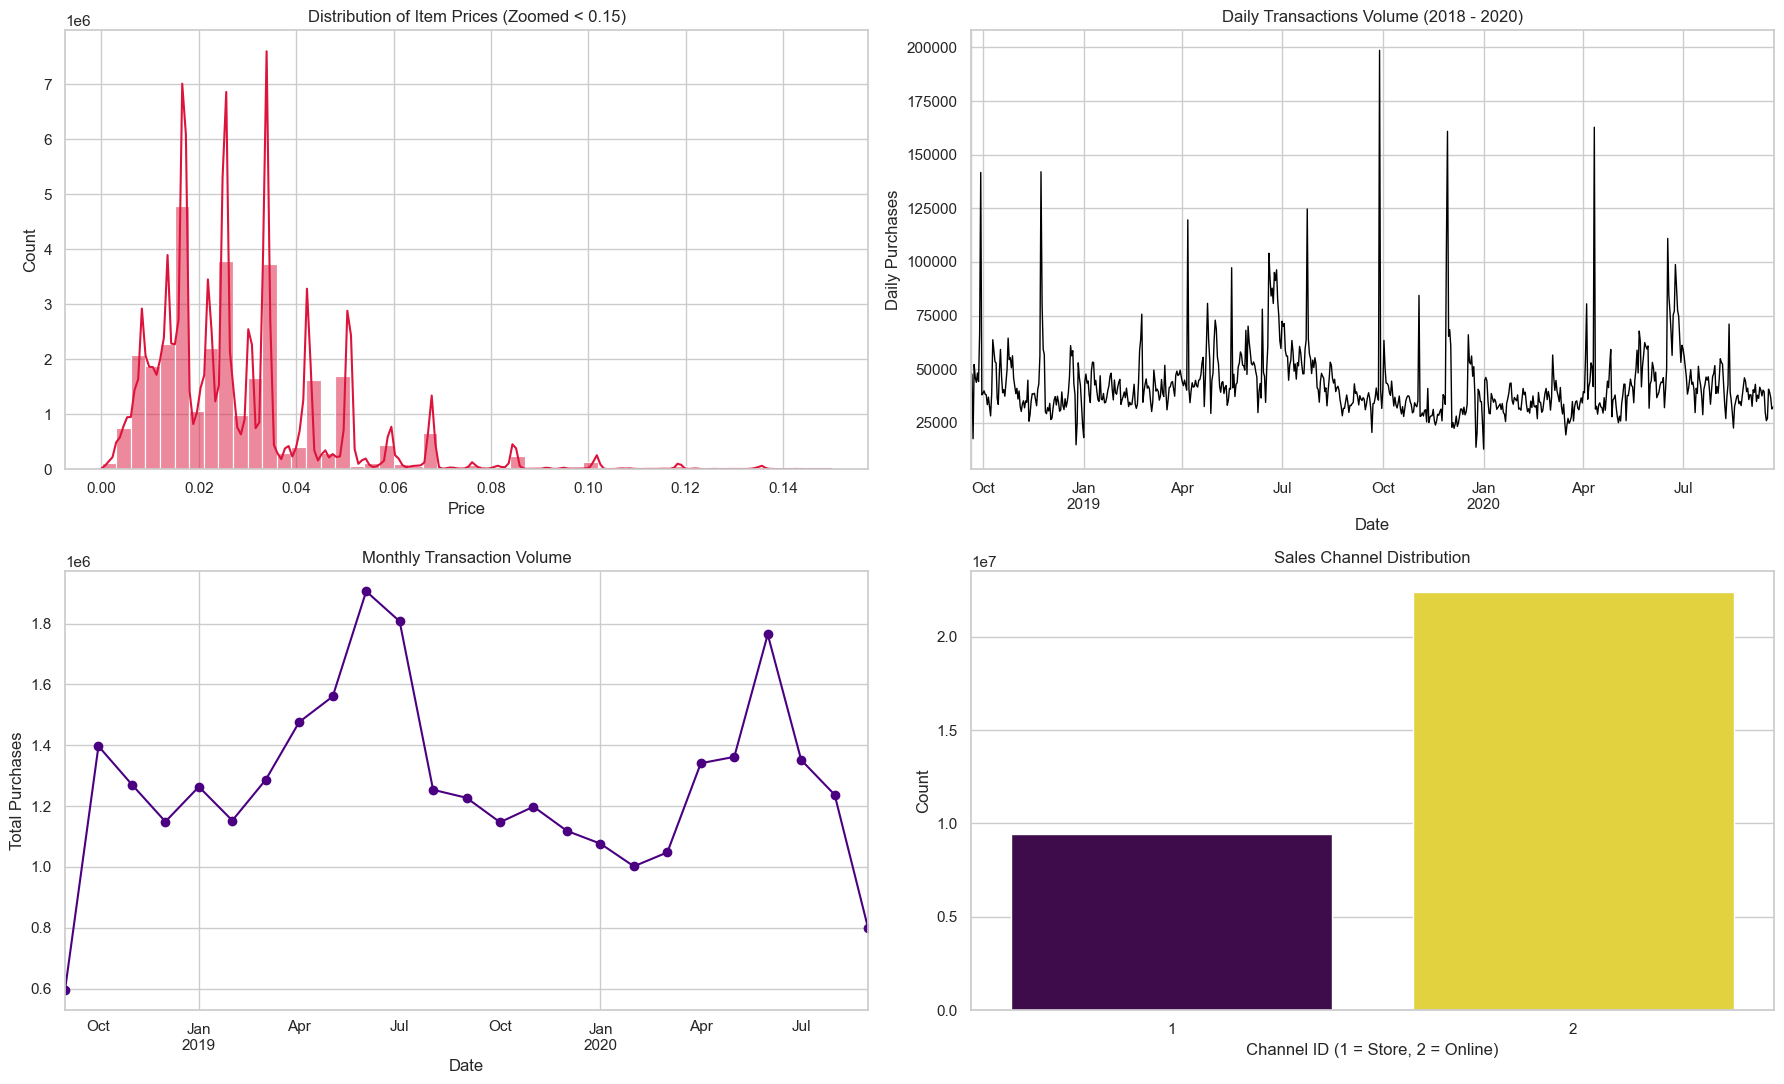

In [4]:
print("--- Transactions Summary ---")
print(f"Total Rows: {len(transactions)}")
print(f"Min Date: {transactions['t_dat'].min().date()}")
print(f"Max Date: {transactions['t_dat'].max().date()}")
print(f"Unique Customers: {transactions['customer_id'].nunique()}")

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# 1. Price Distribution
sns.histplot(
    transactions[transactions['price'] < 0.15]['price'], 
    bins=50, 
    kde=True, 
    color='crimson', 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Distribution of Item Prices (Zoomed < 0.15)')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Count')

# 2. Daily Transactions Over Time
daily_sales = transactions.groupby('t_dat').size()
daily_sales.plot(color='black', ax=axes[0, 1], lw=1)
axes[0, 1].set_title('Daily Transactions Volume (2018 - 2020)')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Daily Purchases')

# 3. Monthly Sales Trend
monthly_sales = transactions.set_index('t_dat').resample('ME').size()
monthly_sales.plot(color='indigo', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Monthly Transaction Volume')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Total Purchases')

# 4. Sales Channel Distribution
sns.countplot(
    data=transactions, 
    x='sales_channel_id', 
    hue='sales_channel_id', 
    palette='viridis',
    legend=False, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Sales Channel Distribution')
axes[1, 1].set_xlabel('Channel ID (1 = Store, 2 = Online)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

--- Normalised Price Statistics (Min-Max: 0 to 1) ---
count    3.178832e+07
mean     4.701932e-02
std      3.242748e-02
min      0.000000e+00
25%      2.670564e-02
50%      4.292387e-02
75%      5.725092e-02
max      1.000000e+00
Name: price_normalized, dtype: float64


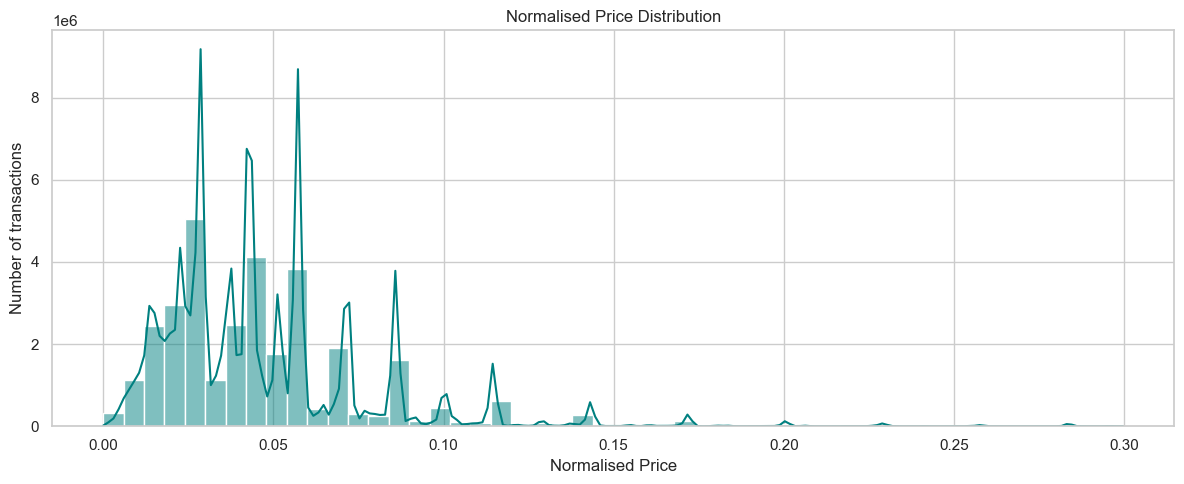

In [5]:
# Initialize MinMaxScaler to bound data exactly between 0 and 1
scaler = MinMaxScaler()
transactions['price_normalized'] = scaler.fit_transform(transactions[['price']])

print("--- Normalised Price Statistics (Min-Max: 0 to 1) ---")
print(transactions['price_normalized'].describe())

plt.figure(figsize=(12, 5))

# We limit the x-axis slightly in the graph to zoom in on the bulk of the data, 
# as fashion pricing is heavily right-skewed (a few very expensive items)
sns.histplot(
    transactions[transactions['price_normalized'] < 0.3]['price_normalized'], 
    bins=50, 
    kde=True, 
    color='teal'
)
plt.title('Normalised Price Distribution')
plt.xlabel('Normalised Price')
plt.ylabel('Number of transactions')

plt.tight_layout()
plt.show()

--- Top 10 Best-Selling Products ---


,article_id,prod_name,purchase_count
0,706016001,Jade HW Skinny Denim TRS,50287
1,706016002,Jade HW Skinny Denim TRS,35043
2,372860001,7p Basic Shaftless,31718
3,610776002,Tilly (1),30199
4,759871002,Tilda tank,26329
5,464297007,Greta Thong Mynta Low 3p,25025
6,372860002,7p Basic Shaftless,24458
7,610776001,Tilly (1),22451
8,399223001,Curvy Jeggings HW Ankle,22236
9,706016003,Jade HW Skinny Denim TRS,21241


--- Top 10 Best-Selling Product Types ---


,product_type_name,purchase_count
111,Trousers,4217017
32,Dress,3238428
99,Sweater,2783274
104,T-shirt,2203750
107,Top,1583408
11,Blouse,1504868
120,Vest top,1414101
15,Bra,1335233
86,Shorts,1152513
8,Bikini top,1126202


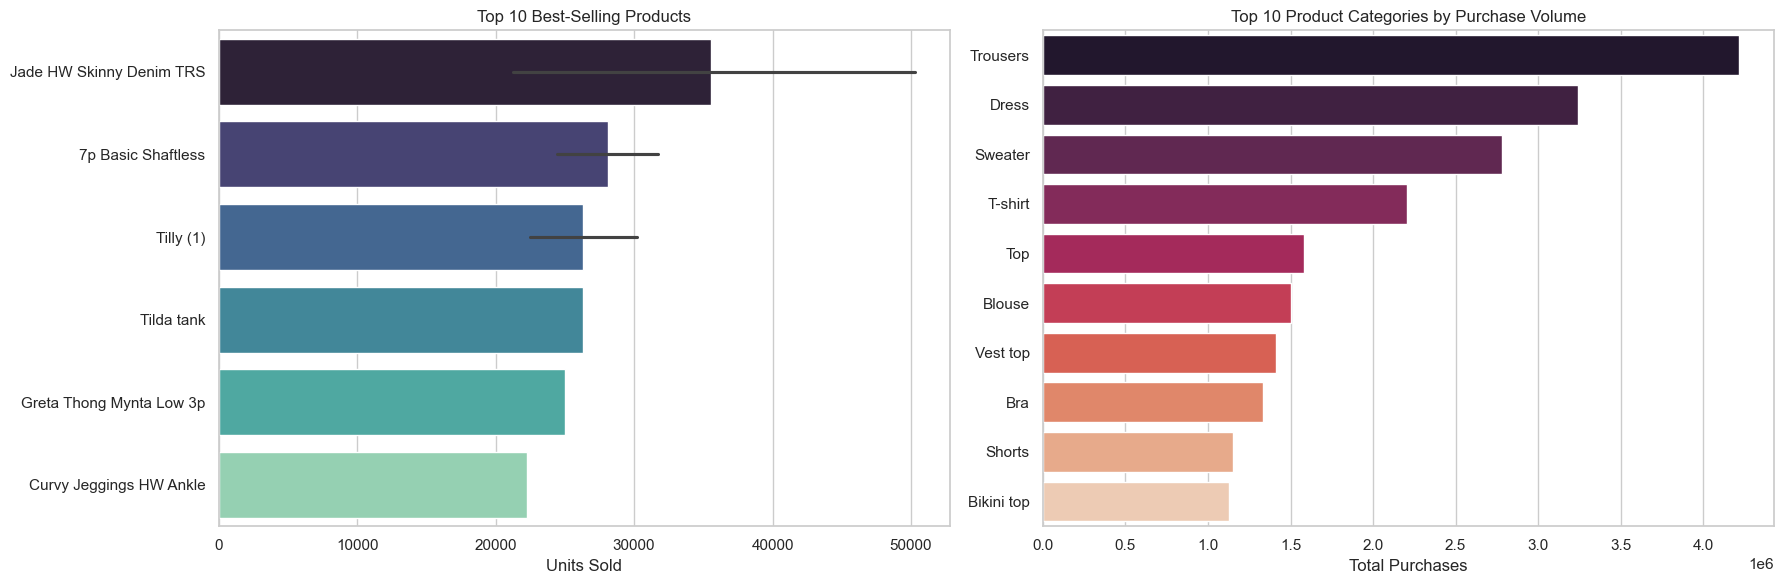

In [6]:
# Aggregate transactions by article_id first to conserve memory
item_counts = transactions['article_id'].value_counts().reset_index()
item_counts.columns = ['article_id', 'purchase_count']

# Merge with articles metadata
best_sellers = item_counts.merge(
    articles[['article_id', 'prod_name', 'product_type_name', 'product_group_name']], 
    on='article_id', 
    how='left'
)

# Table 1: Top 10 Products
top_products_table = best_sellers[['article_id', 'prod_name', 'purchase_count']].head(10)
print("--- Top 10 Best-Selling Products ---")
display(top_products_table)

# Table 2: Top 10 Categories
category_counts = (
    best_sellers.groupby('product_type_name')['purchase_count']
    .sum()
    .reset_index()
    .sort_values('purchase_count', ascending=False)
)
print("--- Top 10 Best-Selling Product Types ---")
display(category_counts.head(10))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Top 10 Products by Name
sns.barplot(
    data=best_sellers.head(10), 
    y='prod_name', 
    x='purchase_count', 
    hue='prod_name', 
    palette='mako', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Top 10 Best-Selling Products')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('')

# Plot Top 10 Categories
sns.barplot(
    data=category_counts.head(10), 
    y='product_type_name', 
    x='purchase_count', 
    hue='product_type_name', 
    palette='rocket', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Top 10 Product Categories by Purchase Volume')
axes[1].set_xlabel('Total Purchases')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

--- Top 10 Revenue-Generating Products ---


,article_id,prod_name,total_revenue
53832,706016001,Jade HW Skinny Denim TRS,1631.732102
53833,706016002,Jade HW Skinny Denim TRS,1136.321085
15980,568601006,Mariette Blazer,939.268593
3087,448509014,Perrie Slim Mom Denim TRS,781.478390
53834,706016003,Jade HW Skinny Denim TRS,692.195915
2233,399223001,Curvy Jeggings HW Ankle,686.484780
58427,720125001,SUPREME RW tights,683.606542
14232,562245046,Luna skinny RW,656.213763
67435,751471001,Pluto RW slacks (1),590.639949
14219,562245001,Luna skinny RW,535.719898


--- Top 10 Revenue-Generating Categories ---


,product_type_name,total_revenue
111,Trousers,150908.046237
32,Dress,118185.796576
99,Sweater,80732.982881
11,Blouse,42424.630475
56,Jacket,40422.762017
89,Skirt,33230.477051
107,Top,32120.533831
15,Bra,31987.636797
104,T-shirt,30274.877153
86,Shorts,26973.206153


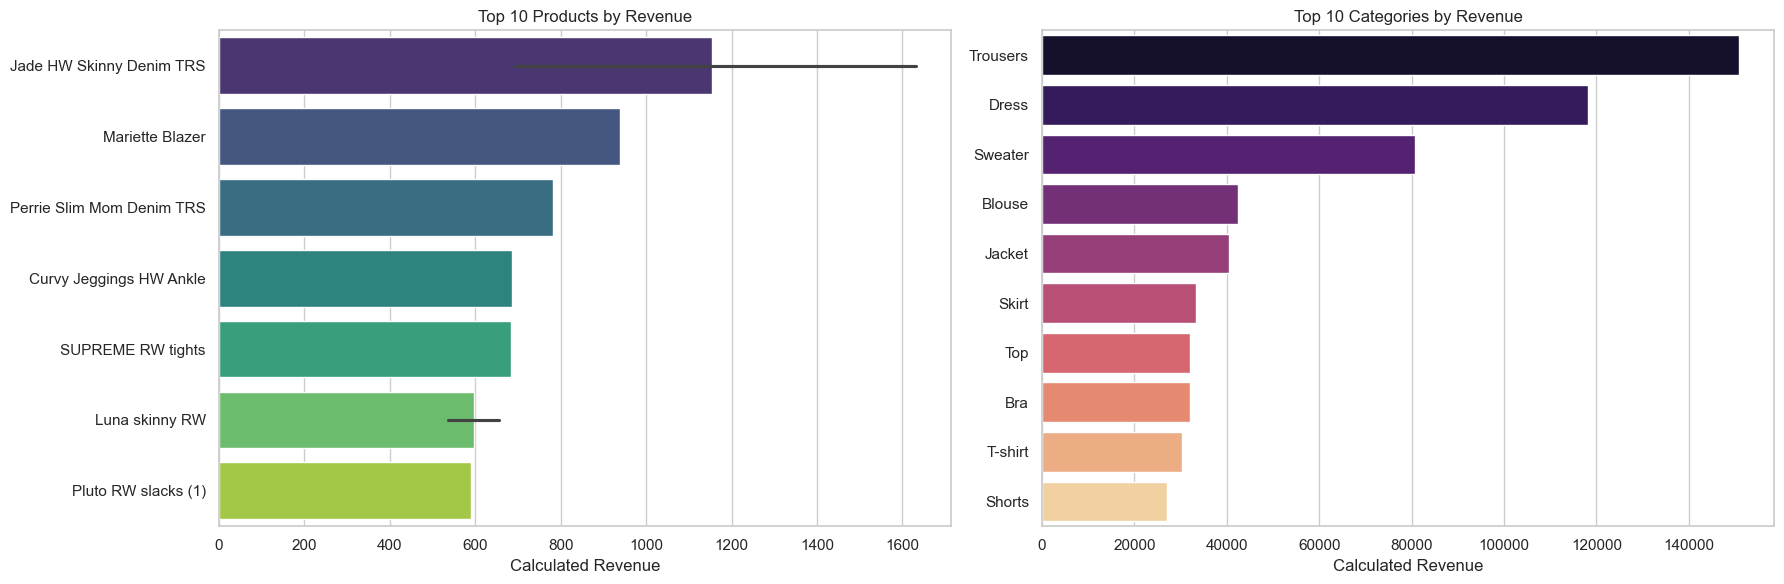

In [7]:
# Calculate revenue per item (sum of price)
item_revenue = transactions.groupby('article_id')['price'].sum().reset_index()
item_revenue.columns = ['article_id', 'total_revenue']

# Merge with metadata
revenue_merged = item_revenue.merge(
    articles[['article_id', 'prod_name', 'product_type_name']], 
    on='article_id', 
    how='left'
).sort_values('total_revenue', ascending=False)

# Table 1: Top 10 Products by Revenue
print("--- Top 10 Revenue-Generating Products ---")
display(revenue_merged[['article_id', 'prod_name', 'total_revenue']].head(10))

# Table 2: Top 10 Categories by Revenue
category_revenue = (
    revenue_merged.groupby('product_type_name')['total_revenue']
    .sum()
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
print("--- Top 10 Revenue-Generating Categories ---")
display(category_revenue.head(10))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=revenue_merged.head(10), 
    y='prod_name', 
    x='total_revenue', 
    hue='prod_name', 
    palette='viridis', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Calculated Revenue')
axes[0].set_ylabel('')

sns.barplot(
    data=category_revenue.head(10), 
    y='product_type_name', 
    x='total_revenue', 
    hue='product_type_name', 
    palette='magma', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Top 10 Categories by Revenue')
axes[1].set_xlabel('Calculated Revenue')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

--- Top 5 Most Active Customers ---


,customer_id,purchase_count
0,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1895
1,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,1441
2,49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05...,1364
3,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,1361
4,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,1237


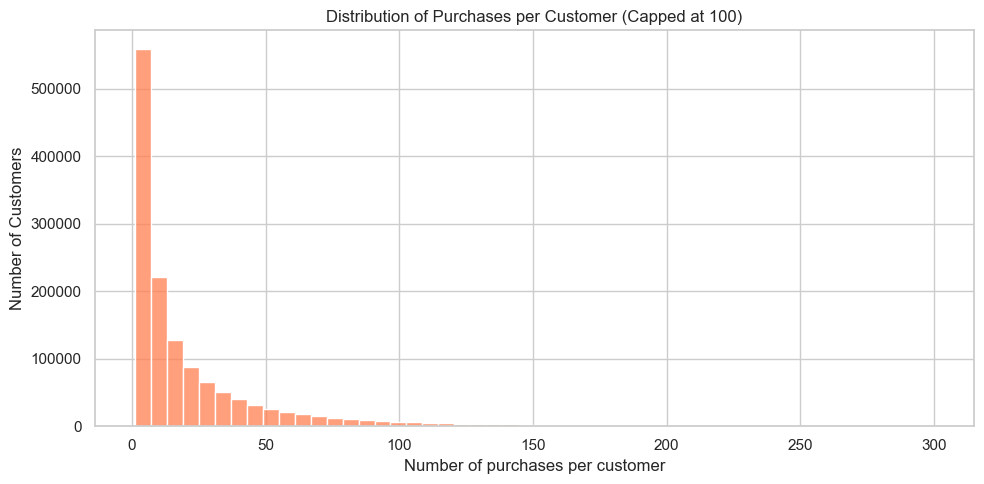

In [8]:
# 1. Best / Most Active Customers
customer_counts = transactions['customer_id'].value_counts().reset_index()
customer_counts.columns = ['customer_id', 'purchase_count']

print("--- Top 5 Most Active Customers ---")
display(customer_counts.head(5))

# 2. Customer Purchase Distribution Graph
plt.figure(figsize=(10, 5))
sns.histplot(
    customer_counts[customer_counts['purchase_count'] <= 300]['purchase_count'], 
    bins=50, 
    color='coral'
)
plt.title('Distribution of Purchases per Customer (Capped at 100)')
plt.xlabel('Number of purchases per customer')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [ ]:
# Aggregating transactions by customer and channel
customer_channel = transactions.groupby(['customer_id', 'sales_channel_id']).size().unstack(fill_value=0)
customer_channel.columns = ['channel_1_store', 'channel_2_online']
customer_channel['total_purchases'] = customer_channel['channel_1_store'] + customer_channel['channel_2_online']

# Most active overall customers
top_customers = customer_channel.sort_values(by='total_purchases', ascending=False).reset_index()

print("--- Top 10 Most Active Customers Across Channels ---")
display(top_customers.head(10))

--- Top 10 Most Active Customers Across Channels ---


,customer_id,channel_1_store,channel_2_online,total_purchases
0,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,361,1534,1895
1,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,10,1431,1441
2,49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05...,49,1315,1364
3,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,30,1331,1361
4,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,0,1237,1237
5,55d15396193dfd45836af3a6269a079efea339e875eff4...,0,1208,1208
6,c140410d72a41ee5e2e3ba3d7f5a860f337f1b5e41c27c...,5,1165,1170
7,8df45859ccd71ef1e48e2ee9d1c65d5728c31c46ae957d...,0,1169,1169
8,03d0011487606c37c1b1ed147fc72f285a50c05f00b971...,77,1080,1157
9,6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2...,1,1142,1143


--- Articles Summary ---
Total Articles: 105542
Unique Product Names: 45875
Top Product Type: Trousers
Top Product Group: Garment Upper body
Top Colour: Black


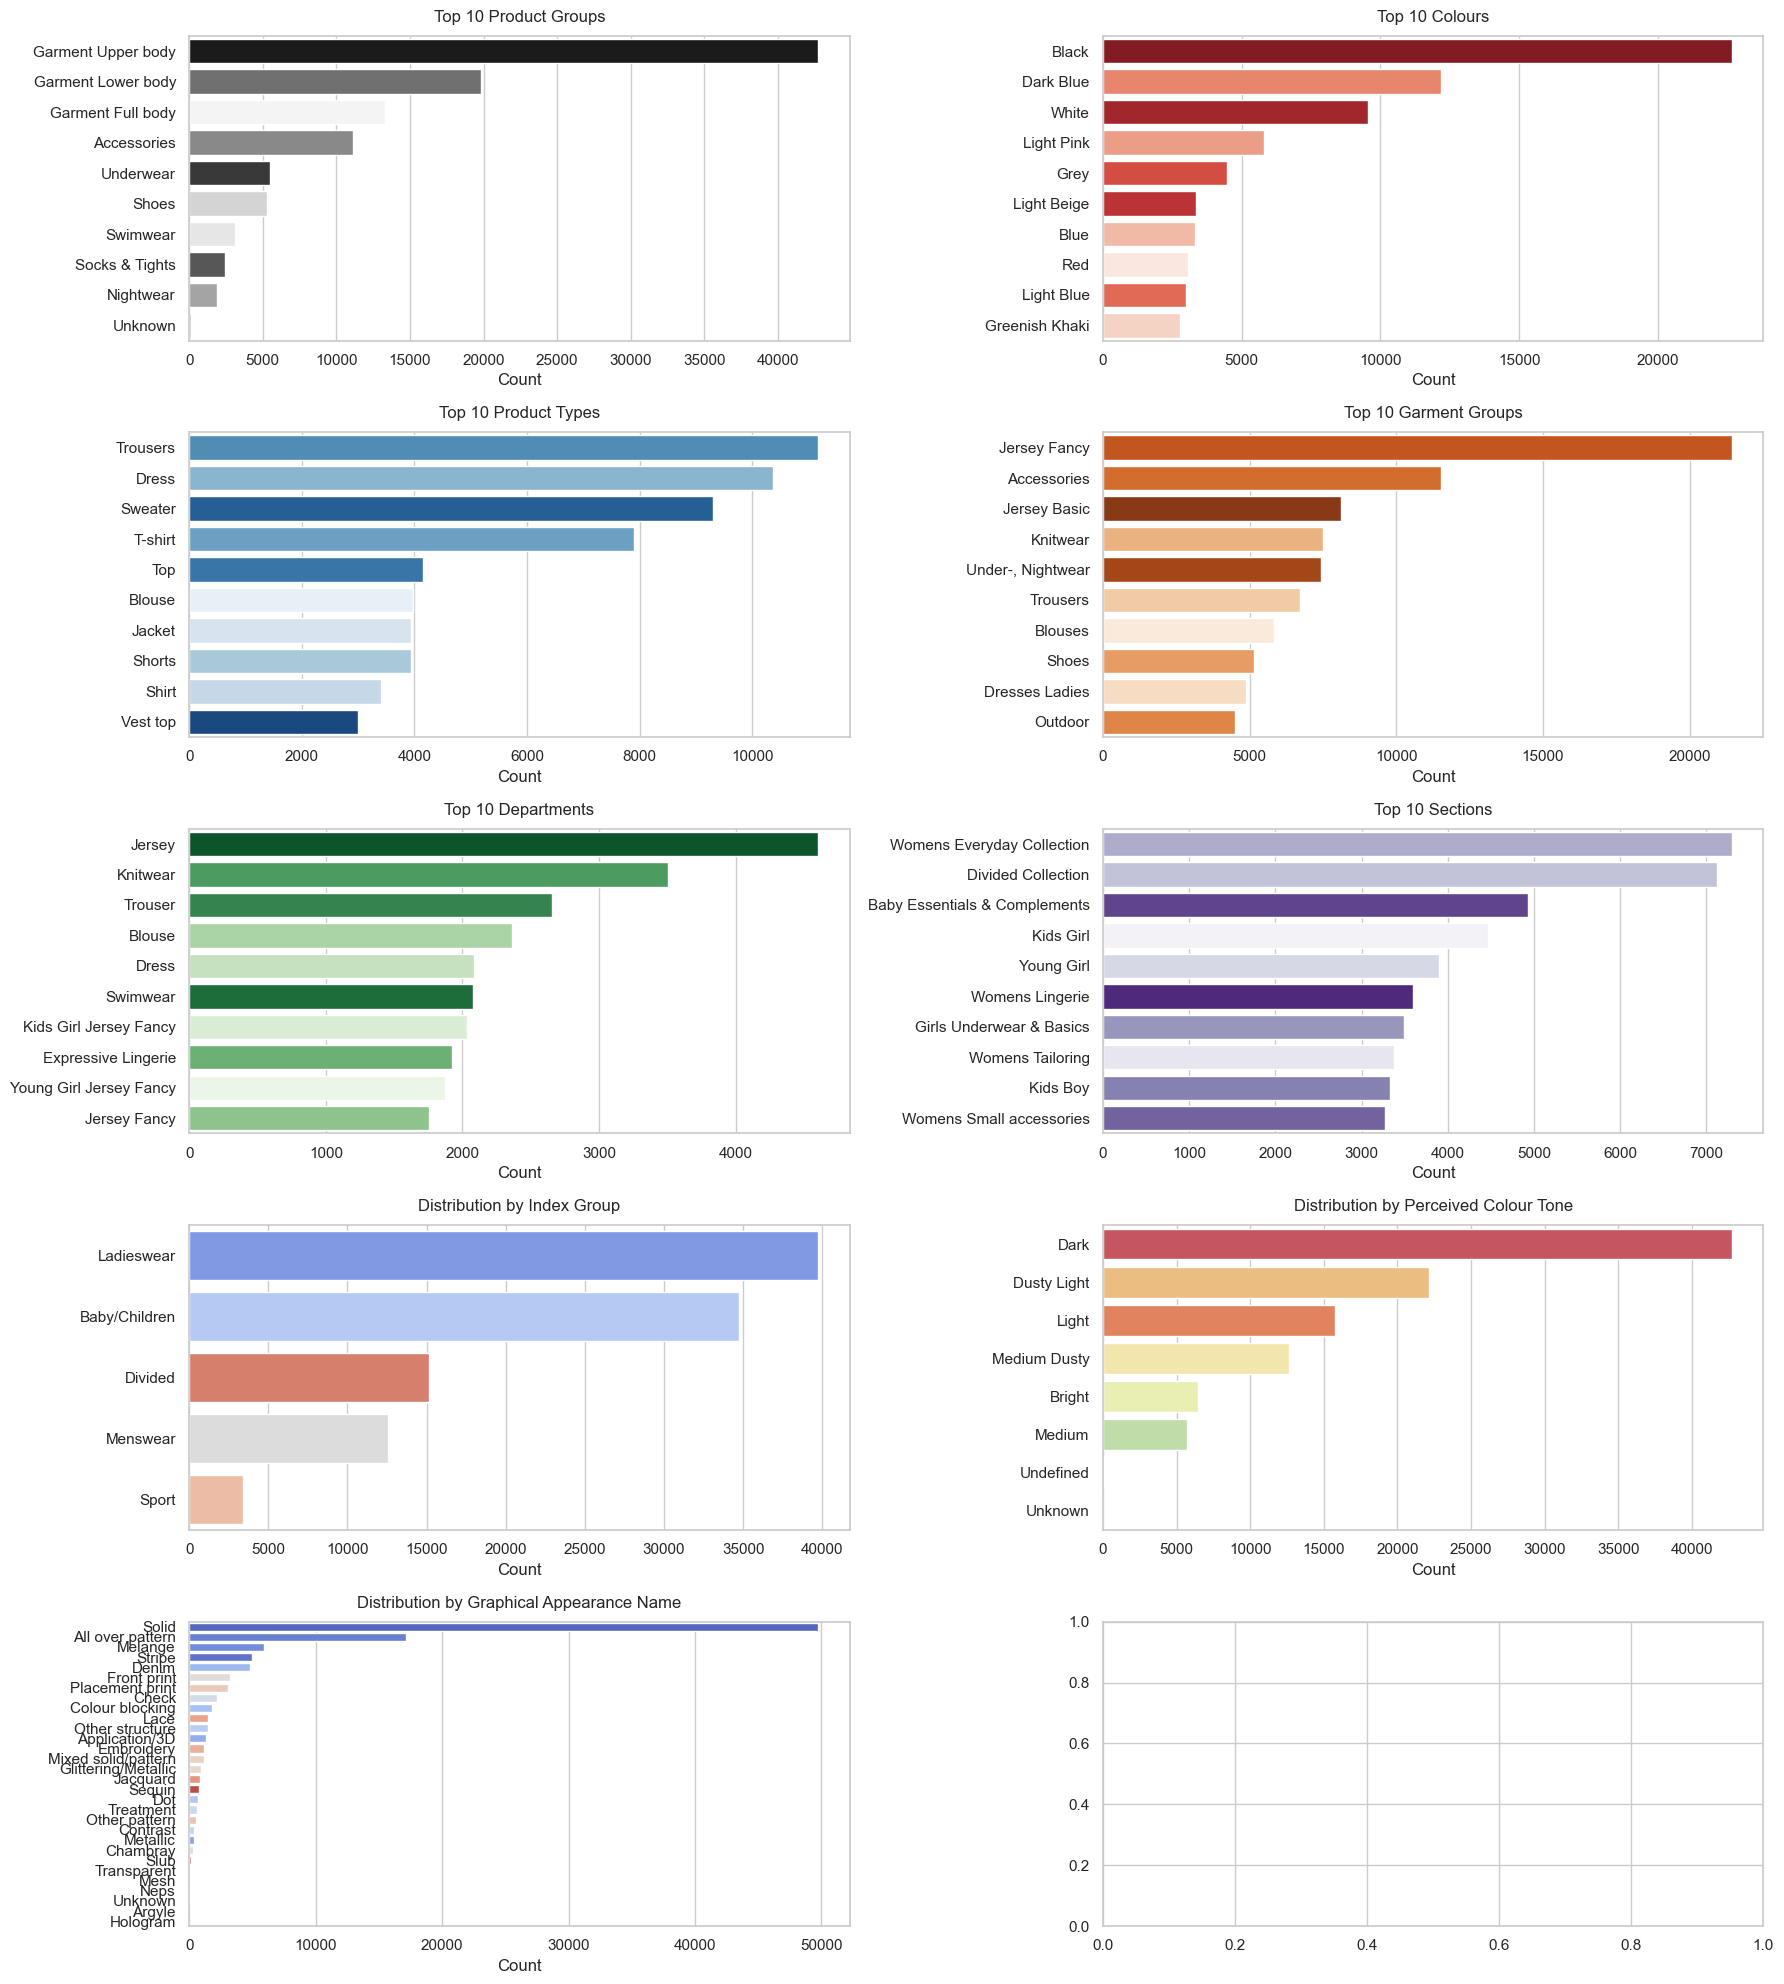

In [ ]:

# High-level summary
print("--- Articles Summary ---")
print(f"Total Articles: {len(articles)}")
print(f"Unique Product Names: {articles['prod_name'].nunique()}")
print(f"Top Product Type: {articles['product_type_name'].mode()[0]}")
print(f"Top Product Group: {articles['product_group_name'].mode()[0]}")
print(f"Top Colour: {articles['colour_group_name'].mode()[0]}")

# Create a 4x2 grid for the 8 plots
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

plot_configs = [
    ('product_group_name', 'Top 10 Product Groups', 'Greys_r', True),
    ('colour_group_name', 'Top 10 Colours', 'Reds_r', True),
    ('product_type_name', 'Top 10 Product Types', 'Blues_r', True),
    ('garment_group_name', 'Top 10 Garment Groups', 'Oranges_r', True),
    ('department_name', 'Top 10 Departments', 'Greens_r', True),
    ('section_name', 'Top 10 Sections', 'Purples_r', True),
    ('index_group_name', 'Distribution by Index Group', 'coolwarm', False),
    ('perceived_colour_value_name', 'Distribution by Perceived Colour Tone', 'Spectral', False),
    ('graphical_appearance_name', 'Distribution by Graphical Appearance Name', 'coolwarm', False)
]

for i, (col, title, palette, top_10_only) in enumerate(plot_configs):
    
    # Determine the sorting order (Top 10 vs. All categories)
    if top_10_only:
        order = articles[col].value_counts().iloc[:10].index
    else:
        order = articles[col].value_counts().index
        
    # Plot using the configured settings
    sns.countplot(
        data=articles[articles[col].isin(order)], 
        y=col, 
        order=order, 
        hue=col, 
        palette=palette, 
        legend=False, 
        ax=axes[i]
    )
    
    axes[i].set_title(title, pad=10)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
def generate_detailed_summary(df, df_name="DataFrame"):
    """
    Iterates through all columns in a DataFrame and generates a Kaggle-style 
    statistical summary based on the inferred data type, including duplicate row tracking.
    """
    total_rows = len(df)
    
    # Calculate duplicate rows across the entire DataFrame
    duplicate_rows = df.duplicated().sum()
    duplicate_pct = (duplicate_rows / total_rows) * 100
    
    print(f"========== DETAILED SUMMARY: {df_name} ==========")
    print(f"Total Rows: {total_rows:,.0f}")
    print(f"Duplicate Rows: {duplicate_rows:,.0f} ({duplicate_pct:.2f}%)\n")
    
    for col in df.columns:
        print(f"--- {col} ---")
        
        # 1. Base Valid/Missing Metrics
        missing = df[col].isnull().sum()
        valid = total_rows - missing
        missing_pct = (missing / total_rows) * 100
        valid_pct = (valid / total_rows) * 100
        
        print(f"Valid: {valid:,.0f} ({valid_pct:.0f}%)")
        print(f"Missing: {missing:,.0f} ({missing_pct:.0f}%)")
        
        # 2. Numeric Column Metrics
        if pd.api.types.is_numeric_dtype(df[col]):
            desc = df[col].describe()
            print(f"Mean: {desc['mean']:.4f}")
            print(f"Std. Deviation: {desc['std']:.4f}")
            print("Quantiles:")
            print(f"  Min:  {desc['min']}")
            print(f"  25%:  {desc['25%']}")
            print(f"  50%:  {desc['50%']}")
            print(f"  75%:  {desc['75%']}")
            print(f"  Max:  {desc['max']}")
            
        # 3. Datetime Column Metrics
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            print(f"Minimum Date: {df[col].min().strftime('%d%b%y')}")
            print(f"Maximum Date: {df[col].max().strftime('%d%b%y')}")
            
        # 4. Categorical / Object Column Metrics
        else:
            unique_count = df[col].nunique()
            print(f"Unique Values: {unique_count:,.0f}")
            
            if unique_count > 0:
                most_common = df[col].mode()[0]
                most_common_freq = (df[col] == most_common).sum()
                most_common_pct = (most_common_freq / valid) * 100
                print(f"Most Common: '{most_common}' ({most_common_pct:.0f}%)")
        
        print("\n") 

In [ ]:
# Dynamic profiler on both datasets
generate_detailed_summary(transactions, "transactions_train.csv")
generate_detailed_summary(articles, "articles.csv")

========== DETAILED SUMMARY: transactions_train.csv ==========
Total Rows: 31,788,324
Duplicate Rows: 2,974,905 (9.36%)

--- t_dat ---
Valid: 31,788,324 (100%)
Missing: 0 (0%)
Minimum Date: 20Sep18
Maximum Date: 22Sep20


--- customer_id ---
Valid: 31,788,324 (100%)
Missing: 0 (0%)
Unique Values: 1,362,281
Most Common: 'be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee985513d9e8e53c6d91b' (0%)


--- article_id ---
Valid: 31,788,324 (100%)
Missing: 0 (0%)
Mean: 696227219.1338
Std. Deviation: 133448003.4874
Quantiles:
  Min:  108775015.0
  25%:  632803008.0
  50%:  714582003.0
  75%:  786524001.0
  Max:  956217002.0


--- price ---
Valid: 31,788,324 (100%)
Missing: 0 (0%)
Mean: 0.0278
Std. Deviation: 0.0192
Quantiles:
  Min:  1.694915254237288e-05
  25%:  0.0158135593220338
  50%:  0.0254067796610169
  75%:  0.0338813559322033
  Max:  0.5915254237288136


--- sales_channel_id ---
Valid: 31,788,324 (100%)
Missing: 0 (0%)
Mean: 1.7040
Std. Deviation: 0.4565
Quantiles:
  Min:  1.0
  25%:  1.0
 

In [ ]:
# Recent transactions used to reduce memory usage
recent_transactions = transactions[
    transactions["t_dat"] >= transactions["t_dat"].max() - pd.Timedelta(days=90)
].copy()

print("Recent transactions shape:", recent_transactions.shape)
print("Unique customers:", recent_transactions["customer_id"].nunique())
print("Unique articles:", recent_transactions["article_id"].nunique())

Recent transactions shape: (3904391, 6)
Unique customers: 525075
Unique articles: 42298


In [ ]:
# ============================================================
# Model 1: Popularity-Based Recommendation System (Last 3 months)
# ============================================================
popular_products = (
    recent_transactions["article_id"]
    .value_counts()
    .reset_index()
)

popular_products.columns = ["article_id", "purchase_count"]

popular_products = popular_products.merge(
    articles[["article_id", "prod_name", "product_type_name", "product_group_name", "colour_group_name", "department_name", "index_name", "section_name", "garment_group_name"]],
    on="article_id",
    how="left"
)

def recommend_popular_products(top_n=15):
    return popular_products.head(top_n)

recommend_popular_products(10)

,article_id,purchase_count,prod_name,product_type_name,product_group_name,colour_group_name,department_name,index_name,section_name,garment_group_name
0,751471001,5870,Pluto RW slacks (1),Trousers,Garment Lower body,Black,Trouser,Ladieswear,Womens Everyday Collection,Trousers
1,706016001,5803,Jade HW Skinny Denim TRS,Trousers,Garment Lower body,Black,Trousers,Divided,Divided Collection,Trousers
2,372860002,4647,7p Basic Shaftless,Socks,Socks & Tights,White,Shopbasket Socks,Lingeries/Tights,"Womens Nightwear, Socks & Tigh",Socks and Tights
3,448509014,4495,Perrie Slim Mom Denim TRS,Trousers,Garment Lower body,Blue,Trousers,Divided,Divided Collection,Trousers
4,610776002,4333,Tilly (1),T-shirt,Garment Upper body,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic
5,730683050,4082,HAVANA HW tights,Unknown,Unknown,Black,Ladies Sport Bottoms,Sport,Ladies H&M Sport,Jersey Fancy
6,866383006,4051,Push it Push Bra,Bikini top,Swimwear,Black,Swimwear,Lingeries/Tights,"Womens Swimwear, beachwear",Swimwear
7,372860001,3825,7p Basic Shaftless,Socks,Socks & Tights,Black,Shopbasket Socks,Lingeries/Tights,"Womens Nightwear, Socks & Tigh",Socks and Tights
8,783346001,3783,Primo slacks,Trousers,Garment Lower body,Black,Trouser,Ladieswear,Womens Everyday Collection,Trousers
9,760084003,3772,Victorville HW Pull-on TRS,Trousers,Garment Lower body,Black,Trousers,Divided,Divided Collection,Trousers


In [15]:
# 1. Enforce the 1-Year Dataset Boundary
max_date = transactions['t_dat'].max()
one_year_ago = max_date - pd.DateOffset(years=1)
tx_1yr = transactions[transactions['t_dat'] >= one_year_ago]

# 2. Chronological Split (Train: First 11 months, Test: Final 30 days)
test_start = max_date - pd.Timedelta(days=30)
train_tx = tx_1yr[tx_1yr['t_dat'] < test_start]
test_tx = tx_1yr[tx_1yr['t_dat'] >= test_start]

# 3. Engineer Numerical Predictors (Behavioral) from Train Data
t_minus_30 = test_start - pd.Timedelta(days=30)
t_minus_7 = test_start - pd.Timedelta(days=7)

behavioral_features = train_tx.groupby('article_id').agg(
    total_hist_sales=('customer_id', 'count'),
    mean_price=('price', 'mean')
).reset_index()

sales_30d = train_tx[train_tx['t_dat'] >= t_minus_30].groupby('article_id').size().reset_index(name='sales_last_30d')
sales_7d = train_tx[train_tx['t_dat'] >= t_minus_7].groupby('article_id').size().reset_index(name='sales_last_7d')

behavioral_features = behavioral_features.merge(sales_30d, on='article_id', how='left').fillna(0)
behavioral_features = behavioral_features.merge(sales_7d, on='article_id', how='left').fillna(0)

# 4. Define the Target Variable from Test Data
target_sales = test_tx.groupby('article_id').size().reset_index(name='target_sales_volume')

# 5. Merge with Expanded Categorical Predictors from Articles
model_df = behavioral_features.merge(target_sales, on='article_id', how='left').fillna(0)

expanded_article_cols = [
    'article_id', 
    'product_type_name', 
    'garment_group_name', 
    'department_name', 
    'colour_group_name', 
    'index_name', 
    'graphical_appearance_name'
]
model_df = model_df.merge(articles[expanded_article_cols], on='article_id', how='inner')

model_df.head()

,article_id,total_hist_sales,mean_price,sales_last_30d,sales_last_7d,target_sales_volume,product_type_name,garment_group_name,department_name,colour_group_name,index_name,graphical_appearance_name
0,108775015,103,0.007306,0.0,0.0,0.0,Vest top,Jersey Basic,Jersey Basic,Black,Ladieswear,Solid
1,108775044,404,0.007741,20.0,1.0,19.0,Vest top,Jersey Basic,Jersey Basic,White,Ladieswear,Solid
2,110065001,155,0.011289,1.0,0.0,0.0,Bra,"Under-, Nightwear",Clean Lingerie,Black,Lingeries/Tights,Solid
3,110065002,65,0.010076,3.0,0.0,0.0,Bra,"Under-, Nightwear",Clean Lingerie,White,Lingeries/Tights,Solid
4,110065011,98,0.011059,0.0,0.0,2.0,Bra,"Under-, Nightwear",Clean Lingerie,Light Beige,Lingeries/Tights,Solid


=== Numerical Predictors Correlation Table ===


,total_hist_sales,sales_last_30d,sales_last_7d,mean_price
total_hist_sales,1.000000,0.589167,0.441119,0.011933
sales_last_30d,0.589167,1.000000,0.807224,-0.000049
sales_last_7d,0.441119,0.807224,1.000000,0.017148
mean_price,0.011933,-0.000049,0.017148,1.000000



=== Categorical Predictors Association Table (Cramér's V) ===


,product_type_name,garment_group_name,department_name,colour_group_name,index_name,graphical_appearance_name
product_type_name,1.000000,0.672831,0.416860,0.140857,0.486101,0.188323
garment_group_name,0.672831,1.000000,0.998172,0.160084,0.466903,0.242301
department_name,0.416860,0.998172,1.000000,0.183182,0.977527,0.301635
colour_group_name,0.140857,0.160084,0.183182,1.000000,0.216556,0.209486
index_name,0.486101,0.466903,0.977527,0.216556,1.000000,0.189708
graphical_appearance_name,0.188323,0.242301,0.301635,0.209486,0.189708,1.000000


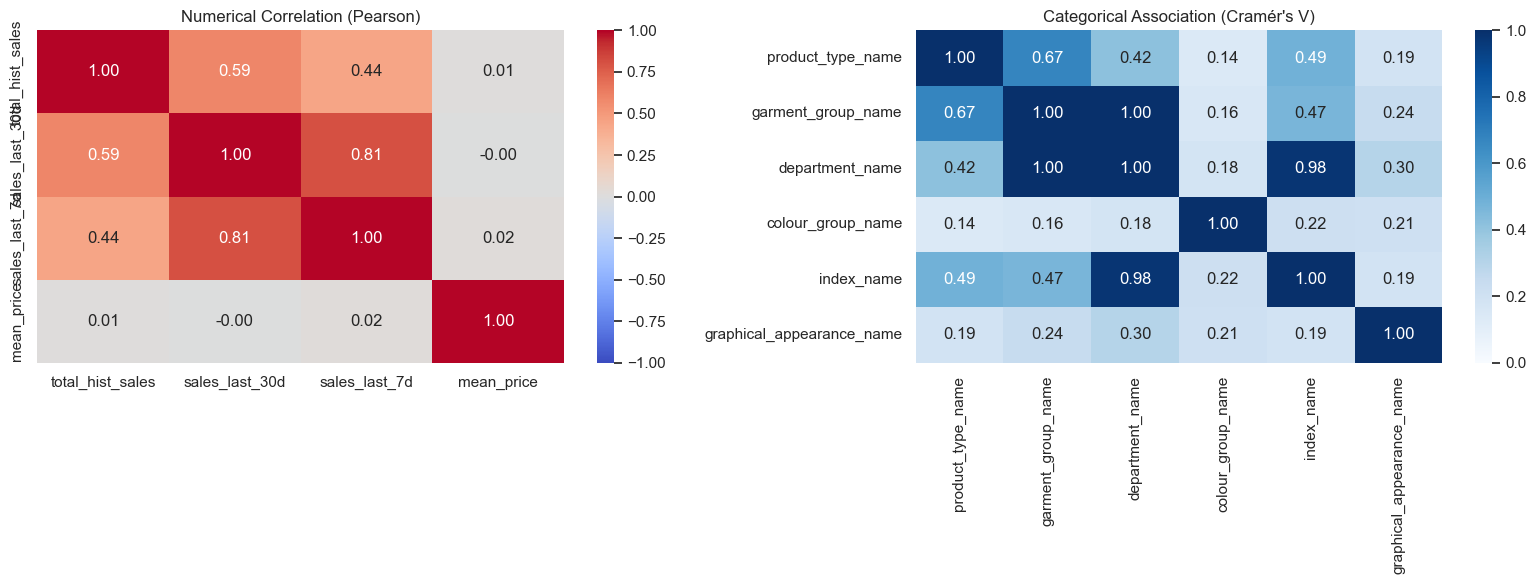

In [16]:
import scipy.stats as ss

# --- 1. Numerical Correlation (Pearson) ---
numeric_cols = ['total_hist_sales', 'sales_last_30d', 'sales_last_7d', 'mean_price']
num_corr_matrix = model_df[numeric_cols].corr()

print("=== Numerical Predictors Correlation Table ===")
display(num_corr_matrix)

# --- 2. Categorical Correlation (Cramér's V) ---
def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = ['product_type_name', 'garment_group_name', 'department_name', 'colour_group_name', 'index_name', 'graphical_appearance_name']
cat_corr_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cat_corr_matrix.loc[col1, col2] = cramers_v(model_df[col1], model_df[col2])

# Convert to float for seaborn plotting
cat_corr_matrix = cat_corr_matrix.astype(float)

print("\n=== Categorical Predictors Association Table (Cramér's V) ===")
display(cat_corr_matrix)

# --- 3. Visualizing Both Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Numerical Heatmap
sns.heatmap(num_corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt=".2f")
axes[0].set_title('Numerical Correlation (Pearson)')

# Categorical Heatmap
sns.heatmap(cat_corr_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, ax=axes[1], fmt=".2f")
axes[1].set_title("Categorical Association (Cramér's V)")

plt.tight_layout()
plt.show()

Calculating Cramér's V for all categories. This may take a minute...


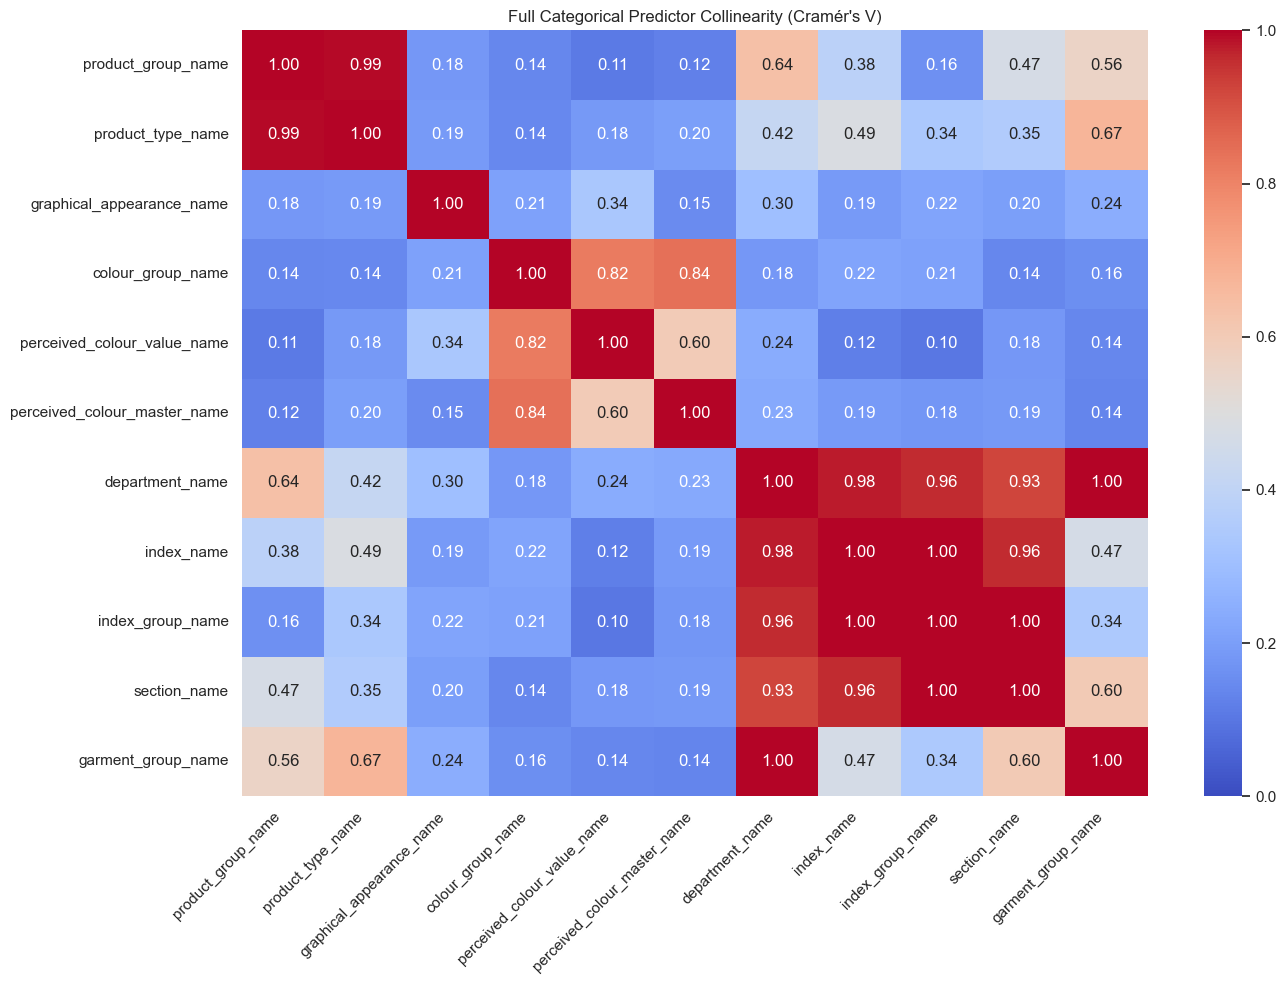

In [ ]:
import scipy.stats as ss

# 1. Define the Cramér's V function
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Get the list of active article_ids from your model_df
active_articles = model_df['article_id'].unique()

corr_df = articles[articles['article_id'].isin(active_articles)].copy()

# 3. The valid descriptive categories
valid_cat_cols = [
    'product_group_name', 'product_type_name', 'graphical_appearance_name',
    'colour_group_name', 'perceived_colour_value_name', 'perceived_colour_master_name',
    'department_name', 'index_name', 'index_group_name', 'section_name', 'garment_group_name'
]

# 4. Build the Correlation Matrix
expanded_corr_matrix = pd.DataFrame(index=valid_cat_cols, columns=valid_cat_cols)

print("Calculating Cramér's V for all categories. This may take a minute...")
for col1 in valid_cat_cols:
    for col2 in valid_cat_cols:
        expanded_corr_matrix.loc[col1, col2] = cramers_v(corr_df[col1], corr_df[col2])

expanded_corr_matrix = expanded_corr_matrix.astype(float)

# 5. Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(expanded_corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f")
plt.title("Full Categorical Predictor Collinearity (Cramér's V)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Prepare Categoricals (Frequency Bucketing & One-Hot Encoding)
final_categoricals = ['product_type_name', 'colour_group_name', 'index_name', 'graphical_appearance_name']

def bucket_categories(df, col, top_n):
    top_categories = df[col].value_counts().nlargest(top_n).index
    return df[col].apply(lambda x: x if x in top_categories else 'Other')

model_df['clean_product_type'] = bucket_categories(model_df, 'product_type_name', 15)
model_df['clean_colour'] = bucket_categories(model_df, 'colour_group_name', 15)
model_df['clean_index'] = bucket_categories(model_df, 'index_name', 5)
model_df['clean_graphical'] = bucket_categories(model_df, 'graphical_appearance_name', 5)

clean_categorical_cols = ['clean_product_type', 'clean_colour', 'clean_index', 'clean_graphical']
encoded_cats = pd.get_dummies(model_df[clean_categorical_cols], drop_first=True, dtype=float)

# 2. Prepare Numericals (Log Transform & MinMax Scaling)
# Using only our finalized, non-collinear numeric predictors
final_raw_numerics = ['total_hist_sales', 'sales_last_30d', 'mean_price']

# Apply log1p to sales columns to handle skew (price doesn't need log)
model_df['total_hist_sales_log'] = np.log1p(model_df['total_hist_sales'])
model_df['sales_last_30d_log'] = np.log1p(model_df['sales_last_30d'])
model_df['mean_price_log'] = model_df['mean_price'] # Just copying for consistent naming

scaler = MinMaxScaler()
cols_to_scale = ['total_hist_sales_log', 'sales_last_30d_log', 'mean_price_log']
scaled_numerics = scaler.fit_transform(model_df[cols_to_scale])

scaled_numerics_df = pd.DataFrame(
    scaled_numerics, 
    columns=['total_hist_sales_scaled', 'sales_last_30d_scaled', 'mean_price_scaled']
)

# 3. Construct Final X Matrix and y Array
X_final = pd.concat([scaled_numerics_df, encoded_cats.reset_index(drop=True)], axis=1)
print(X_final.columns)

# Ensuring target is also log-transformed for stable training
model_df['target_sales_log'] = np.log1p(model_df['target_sales_volume'])
y = model_df['target_sales_log']

# 4. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

models = {
    "Ridge Regression (Baseline)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

results = []
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
print("=== Model Evaluation Results ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Exponentiate to get real units
    y_test_real = np.expm1(y_test)
    preds_real = np.expm1(preds)
    
    mae = mean_absolute_error(y_test_real, preds_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
    r2 = r2_score(y_test_real, preds_real) # Added R-squared
    
    results.append({'Model': name, 'MAE (Units)': mae, 'RMSE (Units)': rmse, 'R2 Score': r2})
    print(f"{name}:\n  MAE:  {mae:.2f}\n  RMSE: {rmse:.2f}\n  R2:   {r2:.4f}\n")

display(pd.DataFrame(results).sort_values(by='MAE (Units)'))

Index(['total_hist_sales_scaled', 'sales_last_30d_scaled', 'mean_price_scaled',
       'clean_product_type_Bra', 'clean_product_type_Dress',
       'clean_product_type_Hoodie', 'clean_product_type_Jacket',
       'clean_product_type_Other', 'clean_product_type_Shirt',
       'clean_product_type_Shorts', 'clean_product_type_Skirt',
       'clean_product_type_Socks', 'clean_product_type_Sweater',
       'clean_product_type_T-shirt', 'clean_product_type_Top',
       'clean_product_type_Trousers', 'clean_product_type_Underwear bottom',
       'clean_product_type_Vest top', 'clean_colour_Black',
       'clean_colour_Blue', 'clean_colour_Dark Blue', 'clean_colour_Dark Grey',
       'clean_colour_Dark Red', 'clean_colour_Greenish Khaki',
       'clean_colour_Grey', 'clean_colour_Light Beige',
       'clean_colour_Light Blue', 'clean_colour_Light Pink',
       'clean_colour_Off White', 'clean_colour_Other', 'clean_colour_Pink',
       'clean_colour_Red', 'clean_colour_White',
       'clean_ind

,Model,MAE (Units),RMSE (Units),R2 Score
2,XGBoost,9.128801,54.261409,0.420416
1,Random Forest,9.318085,54.572080,0.413760
0,Ridge Regression (Baseline),10.430111,62.419780,0.233029


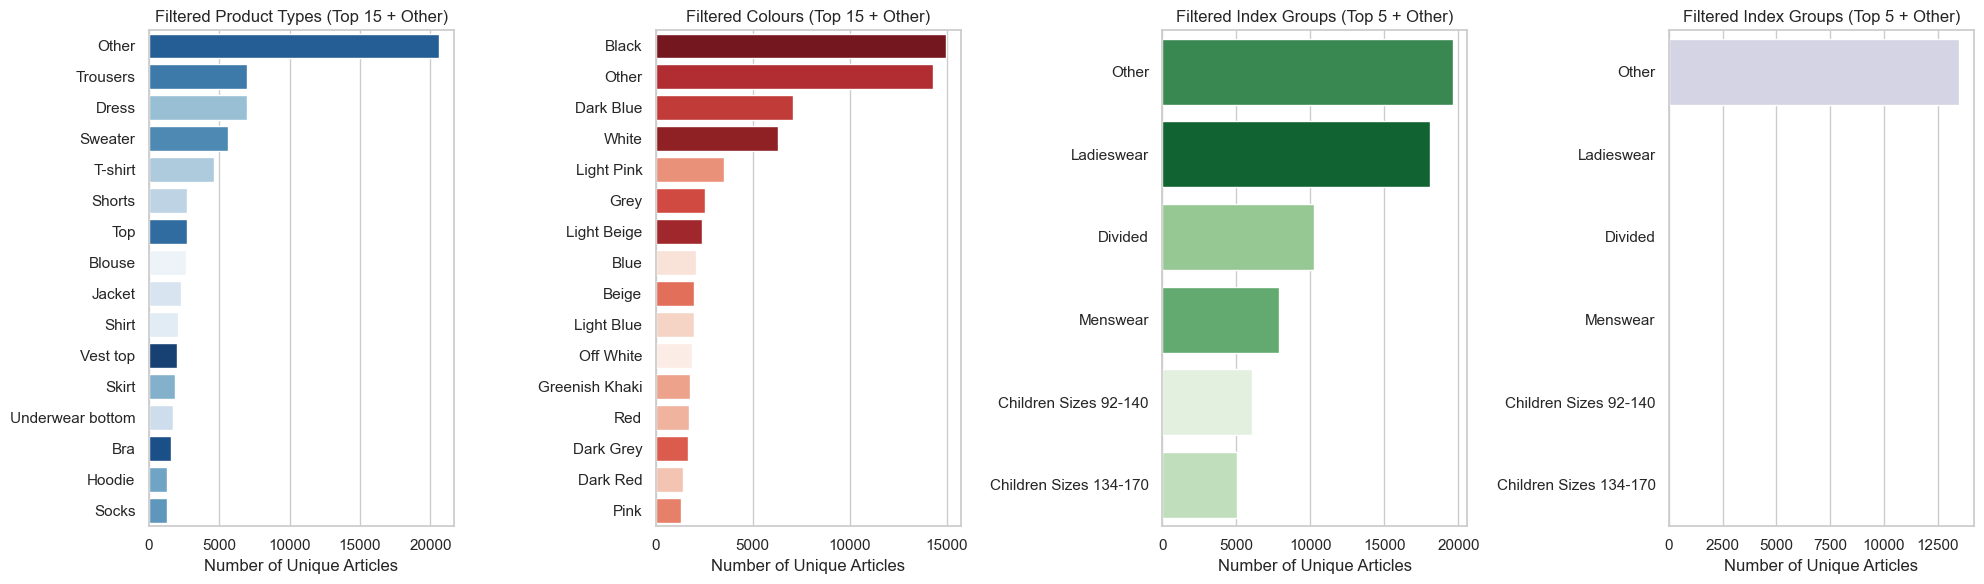

In [ ]:
# Create a 1x3 grid for our three cleaned categorical features
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# 1. Clean Product Type
sns.countplot(
    data=model_df, 
    y='clean_product_type', 
    order=model_df['clean_product_type'].value_counts().index, 
    palette='Blues_r', 
    ax=axes[0],
    legend=False,
    hue='clean_product_type'
)
axes[0].set_title('Filtered Product Types (Top 15 + Other)')
axes[0].set_xlabel('Number of Unique Articles')
axes[0].set_ylabel('')

# 2. Clean Colour
sns.countplot(
    data=model_df, 
    y='clean_colour', 
    order=model_df['clean_colour'].value_counts().index, 
    palette='Reds_r', 
    ax=axes[1],
    legend=False,
    hue='clean_colour'
)
axes[1].set_title('Filtered Colours (Top 15 + Other)')
axes[1].set_xlabel('Number of Unique Articles')
axes[1].set_ylabel('')

# 3. Clean Index
sns.countplot(
    data=model_df, 
    y='clean_index', 
    order=model_df['clean_index'].value_counts().index, 
    palette='Greens_r', 
    ax=axes[2],
    legend=False,
    hue='clean_index'
)
axes[2].set_title('Filtered Index Groups (Top 5 + Other)')
axes[2].set_xlabel('Number of Unique Articles')
axes[2].set_ylabel('')

# 4. Graphical Index
sns.countplot(
    data=model_df, 
    y='clean_graphical', 
    order=model_df['clean_index'].value_counts().index, 
    palette='Purples_r', 
    ax=axes[3],
    legend=False,
    hue='clean_graphical'
)
axes[3].set_title('Filtered Index Groups (Top 5 + Other)')
axes[3].set_xlabel('Number of Unique Articles')
axes[3].set_ylabel('')

plt.tight_layout()
plt.show()

In [40]:
# 1. Isolate the Winning Model
best_model = models["XGBoost"]

# 2. Predict future 30-day sales for the entire active catalog
# We exponentiate immediately to convert the log predictions back to actual garment units
all_predictions = np.expm1(best_model.predict(X_final))

# 3. Attach predictions to the readable item details
predictions_df = model_df[[
    'article_id', 
    'product_type_name', 
    'colour_group_name', 
    'index_name', 
    'graphical_appearance_name'
]].copy()

predictions_df['predicted_30d_sales_volume'] = all_predictions

# 4. Rank the items to find the "Strong Performers"
top_styles_forecast = predictions_df.sort_values(by='predicted_30d_sales_volume', ascending=False)

# 5. Display the Top 20 Forecasted Styles for the Next Period
print("=== TASK 1 OUTPUT: Top Forecasted Styles for Next 30 Days ===")
display(top_styles_forecast.head(20))

=== TASK 1 OUTPUT: Top Forecasted Styles for Next 30 Days ===


,article_id,product_type_name,colour_group_name,index_name,graphical_appearance_name,predicted_30d_sales_volume
36575,759814009,Trousers,Black,Divided,Solid,1457.973145
24182,706016001,Trousers,Black,Divided,Solid,1390.599731
19750,685814001,Hoodie,Black,Menswear,Solid,1324.006592
34251,751471001,Trousers,Black,Ladieswear,Solid,1300.997803
19752,685814003,Hoodie,White,Menswear,Solid,1162.410034
56,160442007,Socks,Black,Lingeries/Tights,Solid,1146.917603
984,372860001,Socks,Black,Lingeries/Tights,Solid,1146.917603
46797,805000001,Hoodie,Black,Sport,Melange,939.744934
37369,762846006,Shirt,Black,Ladieswear,Solid,909.285583
24184,706016003,Trousers,Dark Blue,Divided,Solid,879.380371


In [ ]:
# ============================================================
# Model 2: Popularity-Based Recommendation System (30 days)
# ============================================================
# Use recent transactions only to reduce memory usage
recent_transactions = transactions[
    transactions["t_dat"] >= transactions["t_dat"].max() - pd.Timedelta(days=30)
].copy()

print("Recent transactions shape:", recent_transactions.shape)
print("Unique customers:", recent_transactions["customer_id"].nunique())
print("Unique articles:", recent_transactions["article_id"].nunique())

popular_products = (
    recent_transactions["article_id"]
    .value_counts()
    .reset_index()
)

popular_products.columns = ["article_id", "purchase_count"]

popular_products = popular_products.merge(
    articles[["article_id", 'product_type_name', 
    'colour_group_name', 
    'index_name', 
    'graphical_appearance_name']],
    on="article_id",
    how="left"
)

def recommend_popular_products(top_n=15):
    return popular_products.head(top_n)

recommend_popular_products(20)

Recent transactions shape: (1155933, 6)
Unique customers: 250619
Unique articles: 29237


,article_id,purchase_count,product_type_name,colour_group_name,index_name,graphical_appearance_name
0,751471001,3012,Trousers,Black,Ladieswear,Solid
1,915529003,2535,Sweater,Black,Ladieswear,Solid
2,915526001,2520,Sweater,Off White,Ladieswear,Solid
3,706016001,2495,Trousers,Black,Divided,Solid
4,918292001,2486,Leggings/Tights,Black,Sport,Melange
5,751471043,2480,Trousers,Black,Ladieswear,Check
6,448509014,2101,Trousers,Blue,Divided,Solid
7,898694001,2075,Blazer,Light Beige,Ladieswear,Melange
8,863595006,1949,Cardigan,Black,Ladieswear,Solid
9,909370001,1868,Dress,Off White,Ladieswear,Jacquard


In [ ]:
# from pathlib import Path

# token = "KAGGLE_TOKEN"

# kaggle_dir = Path.home() / ".kaggle"
# kaggle_dir.mkdir(exist_ok=True)

# token_path = kaggle_dir / "access_token"
# token_path.write_text(token.strip())

# # Restrict permissions so only your user can read it
# os.chmod(token_path, 0o600)

# print("Kaggle access token saved successfully!")

In [46]:
# !python -m kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f images/075/0759814009.jpg -p images
# !python -m kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f images/068/0685814001.jpg -p images
# !python -m kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f images/076/0762846006.jpg -p images

In [ ]:
# Verify assumptions based on previous TURN
assert 'best_model' in globals(), "Error: Winning XGBoost model (best_model) not found. Train models first."
assert 'scaler' in globals(), "Error: MinMaxScaler object (scaler) not found. Run numerical prep first."
assert 'X_final' in globals(), "Error: X_final feature matrix not found. Run final matrix construction first."
assert 'model_df' in globals(), "Error: model_df containing article traits not found."

# Creating target directories locally (assuming current directory context)
base_path = "." # Set to current directory
processed_data_path = os.path.join(base_path, "data/processed")
models_path = os.path.join(base_path, "models")

# Guarantee directories exist
os.makedirs(processed_data_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

print("--- Starting Modular Artifact Export ---")

# ==========================================
# 1. Export Model Artifacts & Schema (Versions Sensitive)
# To avoid breaks on other systems, ensure the target system has identical 
# versions of joblib, scikit-learn, and xgboost installed.
# ==========================================

# A. Save the Winning Champion Model (XGBoost)
model_filename = os.path.join(models_path, "xgboost_sales_model.joblib")
joblib.dump(best_model, model_filename)
print(f"✅ Exported champion model: {model_filename}")

# B. Save the Fitted Scaler (MinMaxScaler)
scaler_filename = os.path.join(models_path, "minmax_scaler.joblib")
joblib.dump(scaler, scaler_filename)
print(f"✅ Exported numerical preprocessor (scaler): {scaler_filename}")

# C. Save the Feature Column Schema
schema_filename = os.path.join(models_path, "feature_schema.joblib")
feature_schema = {
    "raw_numerical_cols": cols_to_scale, # The input list for scaling prep
    "final_X_columns": list(X_final.columns) # The strict ordering of OHE + Scaled columns
}
joblib.dump(feature_schema, schema_filename)
print(f"✅ Exported column schema: {schema_filename}")


# ==========================================
# 2. Export Processed Data & Test Splits (Case/Version Agnostic via Parquet)
# ==========================================

# Parquet is used as it preserves datatypes perfectly (OHE uint8, float64, int64) 
# and column ordering, reducing friction when moving out of Jupyter.

# A. Save held-out Test Sets for standalone metric verification in OOP Pipeline
if 'X_test' in globals() and 'y_test' in globals():
    X_test_filename = os.path.join(processed_data_path, "X_test.parquet")
    X_test.to_parquet(X_test_filename, index=False)
    
    # Convert target Series to single-column DataFrame for Parquet support
    y_test_df = y_test.to_frame(name="target_sales_log")
    y_test_filename = os.path.join(processed_data_path, "y_test.parquet")
    y_test_df.to_parquet(y_test_filename, index=False)
    
    print(f"✅ Exported held-out test splits (Features and Labels) to data/processed/")

# B. Save Full ACTIVE Feature Matrix for final inference pipeline
X_final_filename = os.path.join(processed_data_path, "X_all_active.parquet")
X_final.to_parquet(X_final_filename, index=False)
print(f"✅ Exported full active feature matrix (X_final) to data/processed/")


# ==========================================
# 3. Export Comprehensive Catalog Context (Readable)
# Satisfying requirement: "add all metrics used to predict as well"
# ==========================================

# Constructed the complete reference metadata table including visual traits
# AND the original numerical baselines that fed the scaled predictors.

complete_metadata_cols = [
    # Identifier
    'article_id', 
    
    # Visual Traits (Design Context)
    'product_type_name', 
    'colour_group_name', 
    'index_name', 
    'graphical_appearance_name',
    
    # Historical Metrics (Explanatory Context)
    'total_hist_sales',
    'sales_last_30d',
    'mean_price'
]

# Ensure cols exist before subsetting
available_cols = [col for col in complete_metadata_cols if col in model_df.columns]
catalog_context_df = model_df[available_cols].copy()

context_filename = os.path.join(processed_data_path, "catalog_context.parquet")
catalog_context_df.to_parquet(context_filename, index=False)

print(f"✅ Exported complete readable catalog context (visuals + historical numericals) to data/processed/")
print("\n--- Artifact Export Complete. Data is now ready for modular .py execution. ---")

--- Starting Modular Artifact Export ---
✅ Exported champion model: ./models/xgboost_sales_model.joblib
✅ Exported numerical preprocessor (scaler): ./models/minmax_scaler.joblib
✅ Exported column schema: ./models/feature_schema.joblib
✅ Exported held-out test splits (Features and Labels) to data/processed/
✅ Exported full active feature matrix (X_final) to data/processed/
✅ Exported complete readable catalog context (visuals + historical numericals) to data/processed/

--- Artifact Export Complete. Data is now ready for modular .py execution. ---


Starting Task 2 Image Generation via Hugging Face...

Generating concept for: Menswear Black Hoodie...
✅ Successfully saved as menswear_black_hoodie.png


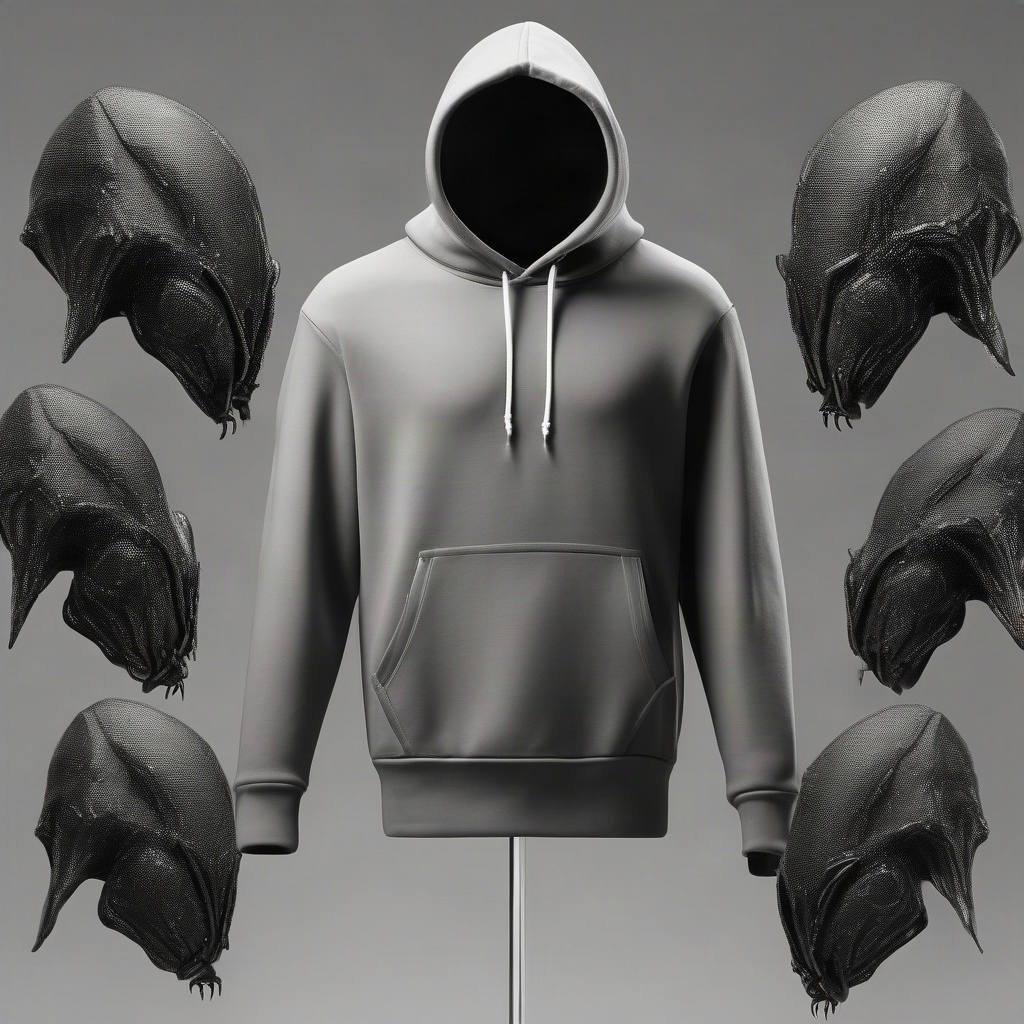

------------------------------------------------------------
Generating concept for: Ladieswear Black Shirt...
✅ Successfully saved as ladieswear_black_shirt.png


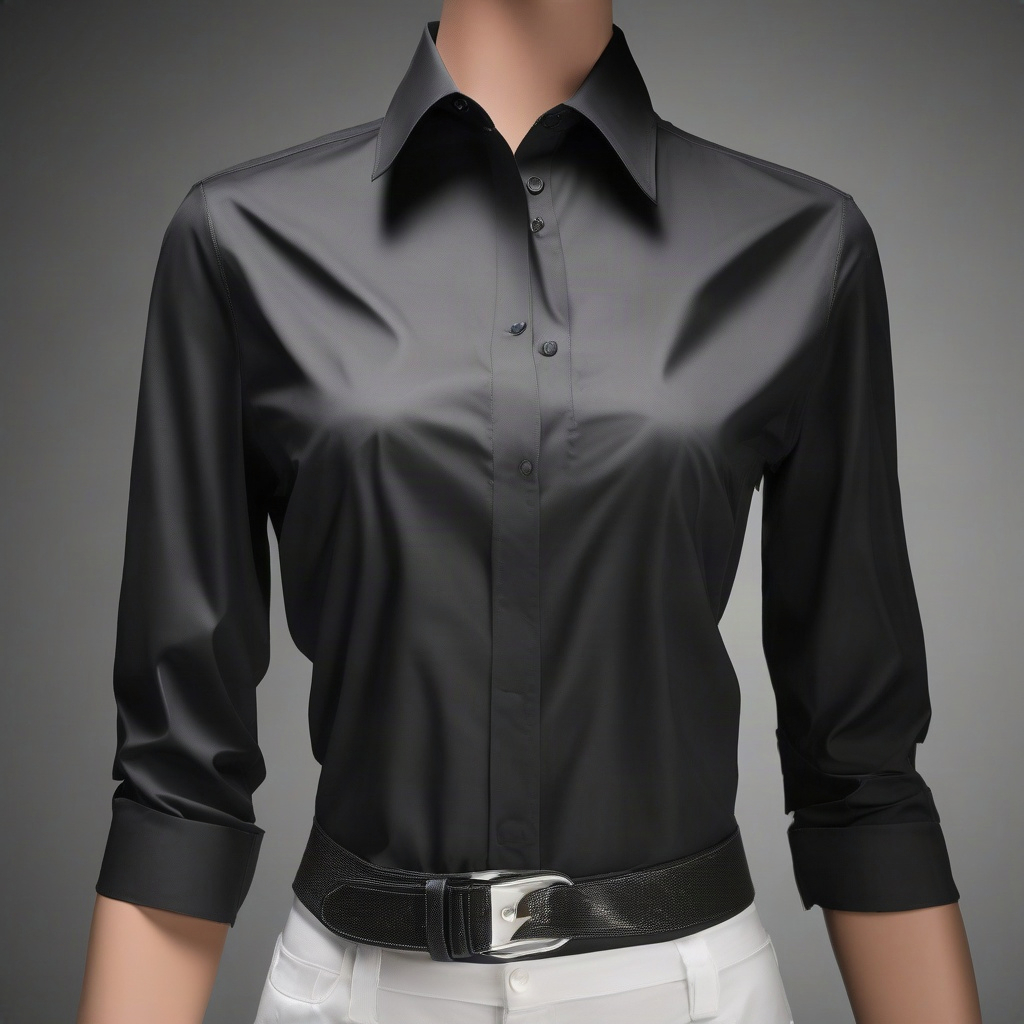

------------------------------------------------------------
Generating concept for: Youth Black Trousers...
❌ Error generating Youth Black Trousers: Client error '402 Payment Required' for url 'https://router.huggingface.co/fal-ai/fal-ai/fast-sdxl' (Request ID: Root=1-6abb64f1-1d992f5635dc082761868d31;2b1abb5f-dc36-4c41-8d3e-709802d1e325)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.


In [ ]:
# from huggingface_hub import InferenceClient
# from IPython.display import display
# from PIL import Image

# # 1. Initialize the Hugging Face Client
# # Replace this string with your actual Hugging Face Access Token
# HF_TOKEN = "HF_TOKEN" 
# client = InferenceClient(token=HF_TOKEN)

# # We use Stable Diffusion XL as it excels at photorealistic fashion generation
# MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

# # 2. Define the Master Style (keeps all 3 images looking like they belong in the same catalog)
# master_style = (
#     "Editorial fashion photography. Minimalist concrete studio floor with "
#     "dramatic top-lighting and a neutral slate-grey background. "
#     "High fashion catalog style, 8k resolution, highly detailed texture, photorealistic."
# )

# # 3. Load your specific, validated design concepts
# designs = [
#     {
#         "name": "Menswear Black Hoodie",
#         "details": "Product catalog shot, single isolated menswear black hoodie on invisible ghost mannequin, "
#             "centered front view. Heavyweight structured cotton fleece. Elevated with an intricate, subtle "
#             "monochrome embroidered beetle motif on the right chest. Clean solid matte black, studio lighting, "
#             "neutral light grey background, photorealistic, 8k commercial listing."
#     },
#     {
#         "name": "Ladieswear Black Shirt",
#         "details":"Product catalog shot, one single isolated ladies casual button-up shirt on invisible ghost mannequin, centered front view. Long full-length sleeves."
#                 "Solid matte black structured woven cotton, zero shine, non-reflective, strictly no satin."
#                  "Features a matching slim fabric waist belt secured by a distinct, highly visible silver metallic buckle clip at the front."
#                  "Editorial fashion photography, uniform studio lighting, neutral light grey background, photorealistic, 8k."
#     },
#     {
#         "name": "Youth Black Trousers",
#         "details": "Product catalog shot, single isolated youth black relaxed track trousers on invisible ghost mannequin, "
#             "centered front view. Slightly baggy drape, deep utility side welt pockets, clean flat waistband "
#             "with completely concealed internal drawstring. "
#     }
# ]

# print("Starting Task 2 Image Generation via Hugging Face...\n")

# # 4. Generate, Save, and Display
# for design in designs:
#     print(f"Generating concept for: {design['name']}...")
    
#     # Combine the specific garment details with the master photography style
#     full_prompt = f"A genuinely new clothing concept for a {design['name']}. {design['details']} {master_style}"
   
#     try:
#         # Call the Hugging Face text-to-image API
#         image = client.text_to_image(full_prompt, model=MODEL_ID)
        
#         # Save the image locally in your current directory
#         filename = f"{design['name'].replace(' ', '_').lower()}.png"
#         image.save(filename)
#         print(f"✅ Successfully saved as {filename}")
        
#         # Display the image inline in the Jupyter output
#         display(image)
#         print("-" * 60)
        
#     except Exception as e:
#         print(f"❌ Error generating {design['name']}: {e}")